# PDoS

Projected electronic density of state versus energy


In [2]:
# Graphene-BC₃ (Hollow)

from vmatplot.PDoS import extract_pdos, extract_segment_pdos
# from vmatplot.PDoS_plotting import *

PBE_total = extract_pdos("4_PDoS_PBE/E_Graphene-BC3_Hollow_K25")
PBE_B     = extract_segment_pdos("4_PDoS_PBE/E_Graphene-BC3_Hollow_K25", 1, 2)
PBE_C_top = extract_segment_pdos("4_PDoS_PBE/E_Graphene-BC3_Hollow_K25", 3, 8)
PBE_C_bot = extract_segment_pdos("4_PDoS_PBE/E_Graphene-BC3_Hollow_K25", 9, 16)

HSE_total = extract_pdos("4_PDoS_HSE06/E_Graphene-BC3_Hollow")
HSE_B     = extract_segment_pdos("4_PDoS_HSE06/E_Graphene-BC3_Hollow", 1, 2)
HSE_C_top = extract_segment_pdos("4_PDoS_HSE06/E_Graphene-BC3_Hollow", 3, 8)
HSE_C_bot = extract_segment_pdos("4_PDoS_HSE06/E_Graphene-BC3_Hollow", 9, 16)

title_total = "Total PDoS"
title_C_top = "PDoS for Carbon in Graphene"
title_B_BC3 = "PDoS for Boron in BC₃"
title_C_BC3 = "PDoS for Carbon in BC₃"

matters_dir = [
    [title_total, 6, 10,    "HSE06", HSE_total, "PBE", PBE_total,],
    [title_C_top, 6, 3,     "HSE06", HSE_C_top, "PBE", PBE_C_top],
    [title_B_BC3, 6, 3,     "HSE06", HSE_B,     "PBE", PBE_B],
    [title_C_BC3, 6, 3,     "HSE06", HSE_C_bot, "PBE", PBE_C_bot],
    ["blue", 1.0, "solid", "blue", 1.0, "dashed"]
]

test_tot = [
    [title_total, 6, 3,    "HSE06", HSE_total, "PBE", PBE_total,],
    ["blue", 1.0, "solid", "blue", 1.0, "dashed"]
]   # Complete

test_sol = [
    [title_total, 6, 10,    "HSE06", HSE_total, "PBE", PBE_total,],
    [title_C_top, 6, 3,    "HSE06", HSE_C_top, "PBE", PBE_C_top],
    ["blue", 1.0, "solid", "blue", 1.0, "dashed"]
]

test_duo = [
    [title_total, 6, 10,    "HSE06", HSE_total, "PBE", PBE_total,],
    [title_C_top, 6, 3,     "HSE06", HSE_C_top, "PBE", PBE_C_top],
    [title_C_BC3, 6, 3,     "HSE06", HSE_C_bot, "PBE", PBE_C_bot],
    ["blue", 1.0, "solid", "blue", 1.0, "dashed"]
]

test_tri = [
    [title_total, 6, 10,    "HSE06", HSE_total, "PBE", PBE_total,],
    [title_C_top, 6, 3,     "HSE06", HSE_C_top, "PBE", PBE_C_top],
    [title_B_BC3, 6, 3,     "HSE06", HSE_B,     "PBE", PBE_B],
    [title_C_BC3, 6, 3,     "HSE06", HSE_C_bot, "PBE", PBE_C_bot],
    ["blue", 1.0, "solid", "blue", 1.0, "dashed"]
]


['HSE06', 'HSE06', 'HSE06', 'HSE06']


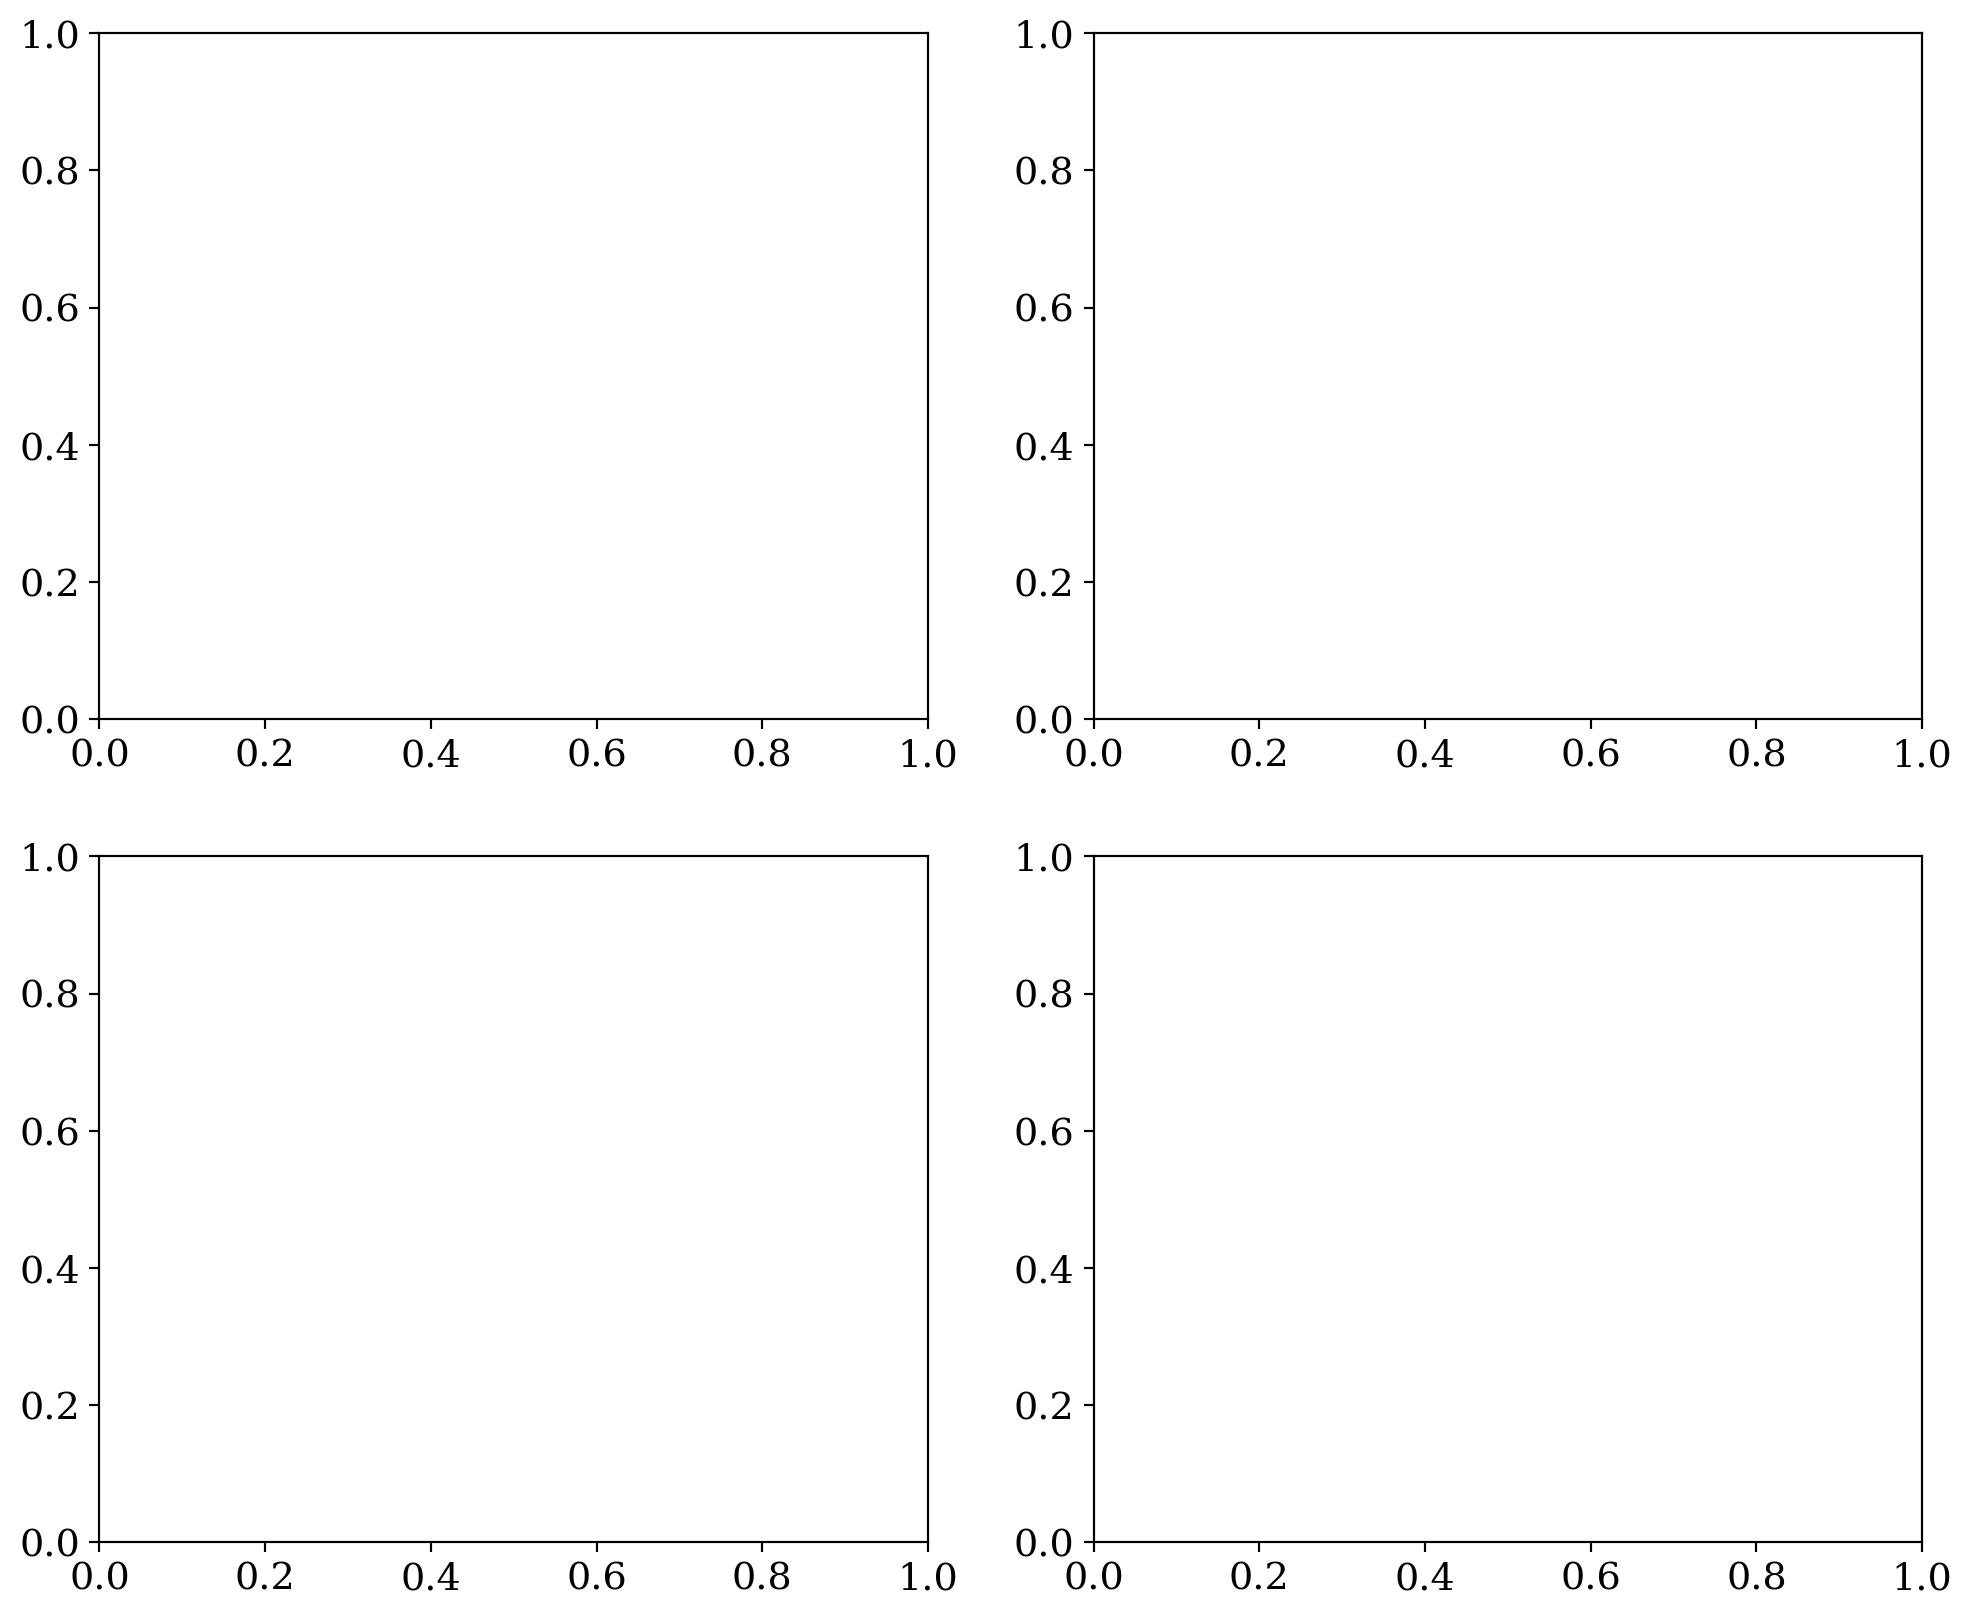

In [12]:
import matplotlib.pyplot as plt

from vmatplot.output import canvas_setting, color_sampling
from vmatplot.PDoS_plotting import plot_total_segment

def plot_tri_segment_pdos(title, matters_list):

    # Figure settings
    fig_setting = canvas_setting(12, 10)
    params = fig_setting[2]; plt.rcParams.update(params)
    fig, axs = plt.subplots(2, 2, figsize=fig_setting[0], dpi=fig_setting[1])
    axes_element = [axs[0, 0], axs[0, 1], axs[1, 0], axs[1, 1]]

    # Colors calling
    fermi_color = color_sampling("Violet")
    annotate_color = color_sampling("Grey")

    # Materials information
    matter = matters_list
    efermi = matter[0][4][0]

    # Ranges
    x_range = []
    y_top   = []
    for index_range in range(4):
        x_range.append(matter[index_range][1])
        y_top.append(matter[index_range][2])

    # Data process
    titles = []
    labels = [[], []] 
    pdoses = [[], []] 
    
    for index_range in range(4):
        titles.append(matter[index_range][0])
        for index_matter in range(len(matter[-1])//3):
            labels[index_matter].append(matter[index_range][3+2*index_matter])
            pdoses[index_matter].append(matter[index_range][4+2*index_matter])

    print(labels[0])

    # label_positions = {0: (1, 0), 1: (0, 0), 2:(1, 1), 3:(0, 1)}

    # fig.suptitle(f"PDoS for {title}", fontsize=fig_setting[3][0])

    # for supplots_index in range(4):
    #     ax = axes_element[supplots_index]
    #     ax.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)
        
    #     pdos_data = pdos_results[supplots_index]
    #     element = elements[supplots_index]

    #     efermi_pdos = pdos_data[0]

    #     if i == 0:
    #         ax.set_title("Total PDoS", fontsize=fig_setting[3][1])
    #         line_width = 1.00
    #         ax.plot(pdos_data[5], pdos_data[6],  c=colors[1], lw=line_width, label=r"Total DoS",  zorder=2)
    #     else:
    #         ax.set_title(f"PDoS for {element}", fontsize=fig_setting[3][1])
    #         line_width = 0.75
    #         ax.plot(pdos_data[5], pdos_data[6],  c=colors[1], lw=line_width, label=r"Total PDoS",  zorder=2)

    #     ax.plot(pdos_data[8], pdos_data[9],  c=colors[3], lw=line_width, label=r"$s$ PDoS",   zorder=3)
    #     ax.plot(pdos_data[8], pdos_data[12], c=colors[4], lw=line_width, label=r"$p_x$ PDoS", zorder=4)
    #     ax.plot(pdos_data[8], pdos_data[10], c=colors[5], lw=line_width, label=r"$p_y$ PDoS", zorder=4)
    #     ax.plot(pdos_data[8], pdos_data[11], c=colors[6], lw=line_width, label=r"$p_z$ PDoS", zorder=4)

    #     ax.set_ylabel(r"Density of states")
    #     ax.set_xlabel(r"Energy (eV)")

    #     shift = efermi_pdos

    #     if i == 0:
    #         y_limit = y_top
    #     elif i == 1:
    #         y_limit = round(y_top * 0.3)
    #     elif i == 2:
    #         y_limit = round(y_top * 0.3)
    #     elif i == 3:
    #         y_limit = round(y_top * 0.3)

    #     ax.axvline(x = efermi_pdos-shift, linestyle="--", c=fermi_color[0], alpha=1.00, label="Fermi energy", zorder=1)
    #     ax.set_ylim(0, y_limit)
    #     ax.set_xlim(-x_range, x_range)
    #     fermi_energy_text = f"Fermi energy\n{efermi_pdos:.3f} (eV)"
    #     if i == 2:
    #         ax.text(efermi_pdos-shift+x_range*0.02, y_limit*0.98, fermi_energy_text, fontsize =1.0*12, c=fermi_color[0], rotation=0, va = "top", ha="left")
    #         ax.legend(loc="upper left")
    #     else:
    #         ax.text(efermi_pdos-shift-x_range*0.02, y_limit*0.98, fermi_energy_text, fontsize =1.0*12, c=fermi_color[0], rotation=0, va = "top", ha="right")
    #         ax.legend(loc="upper right")

    #     x_label, y_label = label_positions[i]
    #     relative_offset = 0.025
    #     if x_label == 0:
    #         ha = "left"; x_label_offset = relative_offset
    #     else:
    #         ha = "right"; x_label_offset = -relative_offset
    #     if y_label == 0:
    #         va = "bottom"; y_label_offset = relative_offset
    #     else:
    #         va = "top"; y_label_offset = -relative_offset

    #     ax.annotate(f"({chr(97 + i)})",
    #                 xy = (x_label + x_label_offset, y_label + y_label_offset),
    #                 xycoords = "axes fraction",
    #                 fontsize = 1.0 * 16,
    #                 ha = ha, va = va,
    #                 bbox = {"facecolor": "white", "alpha": 0.75, "edgecolor": annotate_color[2], "linewidth": 1.5, "boxstyle": "round, pad=0.2"}, zorder=5)

    # plt.tight_layout()

plot_seg_helo_info = "help information"
plot_seg_usage = plot_seg_helo_info
def plot_segment_pdos(*args):
    if len(args) == 1:
        print(plot_seg_helo_info)
    if len(args) == 2:
        if len(args[1]) == 1:
            print("Format error")
            print(plot_seg_usage)
        if len(args[1]) == 2:
            return plot_total_segment(args[0], args[1])
        # if len(args[1]) == 3:
        #     return plot_sol_segment_pdos(args[0], args[1])
        # if len(args[1]) == 4:
        #     return plot_duo_segment_pdos(args[0], args[1])
        if len(args[1]) == 5:
            return plot_tri_segment_pdos(args[0], args[1])

plot_segment_pdos("Testing material", test_tri)

In [3]:
# # Graphene-Borophene (Top)

# from vmatplot.PDoS import extract_pdos, extract_segment_pdos
# from vmatplot.PDoS_plotting import *

# PBE_total = extract_pdos("4_PDoS_PBE/F_Graphene-Borophene_Top_K25")
# PBE_B     = extract_segment_pdos("4_PDoS_PBE/F_Graphene-Borophene_Top_K25", 1, 8)
# PBE_C_top = extract_segment_pdos("4_PDoS_PBE/F_Graphene-Borophene_Top_K25", 9, 16)

# HSE_total = extract_pdos("4_PDoS_HSE06/F_Graphene-Borophene_Top_K25")
# HSE_B     = extract_segment_pdos("4_PDoS_HSE06/F_Graphene-Borophene_Top_K25", 1, 8)
# HSE_C_top = extract_segment_pdos("4_PDoS_HSE06/F_Graphene-Borophene_Top_K25", 9, 16)

# title_total = "Total PDoS"
# title_C_top = "PDoS for Carbon in Graphene"
# title_B     = "PDoS for Boron in Borophene"

# matters_dir = [
#     [title_total, 6, 10,    "PBE", PBE_total,   "HSE06", HSE_total],
#     [title_C_top, 6, 4.5,   "PBE", PBE_C_top,   "HSE06", HSE_C_top],
#     [title_B,     6, 4.5,   "PBE", PBE_B,       "HSE06", HSE_B]
# ]

In [4]:
# # Graphene-B₄C₃ (Top)

# from vmatplot.PDoS import extract_pdos, extract_segment_pdos
# from vmatplot.PDoS_plotting import *

# PBE_total = extract_pdos("4_PDoS_PBE/G_Graphene-B4C3_Top_K25")
# PBE_B     = extract_segment_pdos("4_PDoS_PBE/G_Graphene-B4C3_Top_K25", 1, 4)
# PBE_C_top = extract_segment_pdos("4_PDoS_PBE/G_Graphene-B4C3_Top_K25", 5, 7)
# PBE_C_bot = extract_segment_pdos("4_PDoS_PBE/G_Graphene-B4C3_Top_K25", 8, 15)

# HSE_total = extract_pdos("4_PDoS_HSE06/G_Graphene-B4C3_Top")
# HSE_B     = extract_segment_pdos("4_PDoS_HSE06/G_Graphene-B4C3_Top", 1, 4)
# HSE_C_top = extract_segment_pdos("4_PDoS_HSE06/G_Graphene-B4C3_Top", 5, 7)
# HSE_C_bot = extract_segment_pdos("4_PDoS_HSE06/G_Graphene-B4C3_Top", 8, 15)

# title_total  = "Total PDoS"
# title_C_top  = "PDoS for Carbon in Graphene"
# title_B_B4C3 = "PDoS for Boron in B₄C₃"
# title_C_B4C3 = "PDoS for Carbon in B₄C₃"

# matters_dir = [
#     [title_total, 6, 10,    "PBE", PBE_total,   "HSE06", HSE_total],
#     [title_C_top, 6, 10,    "PBE", PBE_C_top,   "HSE06", HSE_C_top],
#     [title_B_B4C3, 6, 3,    "PBE", PBE_B,       "HSE06", HSE_B],
#     [title_C_B4C3, 6, 3,    "PBE", PBE_C_bot,   "HSE06", HSE_C_bot]
# ]
